In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt
import corner


import numpyro, os, json
import numpyro.distributions as dist
import jax.numpy as jnp
from numpyro.infer import Predictive
import arviz as az
import jax

from numpyro import handlers
from numpyro.infer import MCMC, NUTS, Predictive

from emulator import Emulator
from utils import norm, unnorm 

from numpyro.handlers import reparam
from numpyro.infer.reparam import LocScaleReparam

from jax import vmap, Array
import tensorflow as tf


2025-02-21 09:43:48.474906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1740131028.486957  659551 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1740131028.490570  659551 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
def sample_beta(param_name, loc, scale, alpha = 2, beta = 2):

    beta_samp = numpyro.sample(f'{param_name}_beta', dist.Beta(alpha, beta))

    return numpyro.deterministic(param_name, loc + scale*beta_samp)

def sample_lognormal(param_name, mu, sig, offset):

    #This is giving a handful of samples that are way off

    log_samp = numpyro.sample(f'{param_name}_log', dist.LogNormal(0, 1))

    return numpyro.deterministic(param_name, mu + sig*log_samp + offset)


In [3]:
normconsts = np.load('../grids/Chiara-normconsts.npy', allow_pickle = True).item()

modelpath = '/home/hatte/M4/models'

n_dense_layers = 2

dense_layer_units = 512

Nepochs = 200000

learning_rate = 0.001

model_name = 'logLPhot'

loss_func = 'MSE'

checkpoint_dir = f'{modelpath}/long-runs/checkpoint/chk-{model_name}-nlayers-{n_dense_layers}-nunits-{dense_layer_units}-epochs-{Nepochs}-lrate-{learning_rate}-lossfunc-{loss_func}.model.keras'

emulator_kwargs =  {'model_name':'logLPhot', 'n_dense_layers':2, 'dense_layer_units':512, 'Nepochs':200000, 'lrate':0.001, \
        'loss':'MSE', 'model_dir':'../models',  'inputs': ['massini', 'zini', 'yini', 'alphaMLT', 'age', 'eta', 'alphaFe'], 'outputs':['FeH', 'logLPhot', 'Teff', 'numax', 'dnuSer'],\
        'normconsts':normconsts, 'checkpoint_dir':checkpoint_dir}

model_outputs = Emulator(emulator_kwargs, normalised = False)



I0000 00:00:1740131030.069680  659551 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1063 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6
I0000 00:00:1740131030.070169  659551 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 10051 MB memory:  -> device: 1, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


In [5]:
df_full = pd.read_hdf('../grids/Chiara.hdf5', key='df')

df_full['logLPhot'] = np.log10(df_full['LPhot'])

inputs = model_outputs.inputs

outputs = ['FeH', 'LPhot', 'Teff', 'numax', 'dnuSer']

hierarchical_params = ['mu_zini', 'std_zini', 'mu_alphaMLT', 'std_alphaMLT', 'mu_age', 'std_age']

df = df_full[inputs+outputs+['logLPhot']]

normconsts['LPhot'] = (np.min(df_full['LPhot']), np.max(df_full['LPhot']))

#Then I pick a hare - I need to try with an emu instead, this was just quick to make sure the sampling runs at all
teststar = df.sample(1)

df_test = df.sample(10000)

# Load a fake cluster

In [6]:
cluster = np.load('./fake-1param-observations-age.npy', allow_pickle = True).item()

num_stars = len(cluster['FeH'])

consts_dict = np.load('./fake-1param-consts-age.npy', allow_pickle = True).item()

h_params = ['mu_age', 'std_age', ]

cluster_df = pd.read_csv('fake-1param-age-df.csv')

In [11]:
consts_dict

{'age': (11000, 50)}

In [8]:
def cluster_model(uncs, consts = consts_dict, obs = model_outputs.obs_dict):

    mu_age = sample_beta('mu_age', consts['age'][0] - 100, 200)

#    mu_age = numpyro.sample('mu_age', dist.Normal(consts['age'][0], 1))

    std_age = sample_lognormal('std_age', consts['age'][1], 150, 5)

    with numpyro.plate("star", num_stars):

        age = numpyro.sample('age', dist.Normal(mu_age, std_age))

        tau = sample_beta('tau', 1, 0.1)

        massini = numpyro.deterministic('massini', 0.6*(age/10**4)**3.2*tau)

        zini = numpyro.sample('zini', dist.Normal(0.006, 0.002))

        yini = numpyro.sample('yini', dist.Normal(0.28, 0.02))

        eta = numpyro.sample('eta', dist.Normal(0.14, 0.05))

        alphaMLT = numpyro.sample('alphaMLT', dist.Normal(1.95, 0.1))

        alphaFe = numpyro.sample('alphaFe', dist.Normal(0, 0.06))
        
        params = jnp.stack([massini, zini, yini, alphaMLT, age, eta, alphaFe], axis = -1)

        pred = model_outputs(params)

        LPhot_out = numpyro.deterministic("LPhot_out", 10**pred[:, 1])

    FeH = numpyro.sample("FeH", dist.Normal(pred[:, 0], uncs['FeH']), obs=obs['FeH'])
    
    LPhot = numpyro.sample("LPhot", dist.Normal(LPhot_out, uncs['LPhot']), obs=obs['LPhot'])

    Teff = numpyro.sample("Teff", dist.Normal(pred[:, 2], uncs['Teff']), obs=obs['Teff'])

    numax = numpyro.sample("numax", dist.Normal(pred[:, 3], uncs['numax']), obs=obs['numax'])

    dnu = numpyro.sample("dnuSer", dist.Normal(pred[:, 4], uncs['dnuSer']), obs=obs['dnuSer'])
   

In [248]:
#def cluster_model(uncs, consts = consts_dict, obs = model_outputs.obs_dict):
#    with numpyro.plate("star", num_stars):
 #       logLPhot = numpyro.sample('logLPhot', dist.LogNormal(np.array(np.log(cluster_df['logLPhot'])), np.log(1)))
    

# Prior Predictive Test

In [9]:
phys_unc = {'Teff':150, 'LPhot':0.01*np.array(cluster_df['LPhot']), 'numax': 10/3090, 'dnuSer':1/135, 'FeH':0.2}
#uncert = jnp.array([phys_unc[i] for i in outputs])*jnp.ones_like(jnp.array(df_obs[outputs]))

In [10]:
rng_key = jax.random.PRNGKey(0)

rng_key, rng_key_ = jax.random.split(rng_key)

prior_predictive = Predictive(cluster_model, num_samples=1000,)

prior = prior_predictive(rng_key_, \
                         uncs=phys_unc, )

#y = prior.pop("y")
#for i, key in enumerate(model_outputs.outputs):
#    prior[key] = y[..., i]
coords = {"star": np.arange(num_stars)}
dims = {}
for key, value in prior.items():
    dims[key] = dim = []
    if value.ndim == 1:
        continue
    if value.shape[-1] == num_stars:
        dim.append("star")

data = az.from_numpyro(prior=prior, coords=coords, dims=dims)
data

Inference data with groups:
	> prior

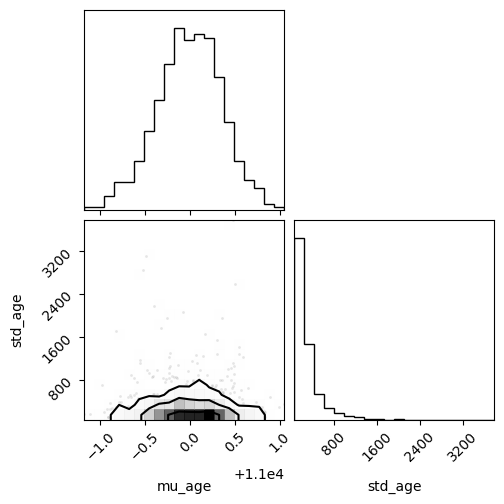

In [251]:
fig = corner.corner(data, group="prior", var_names=h_params, )

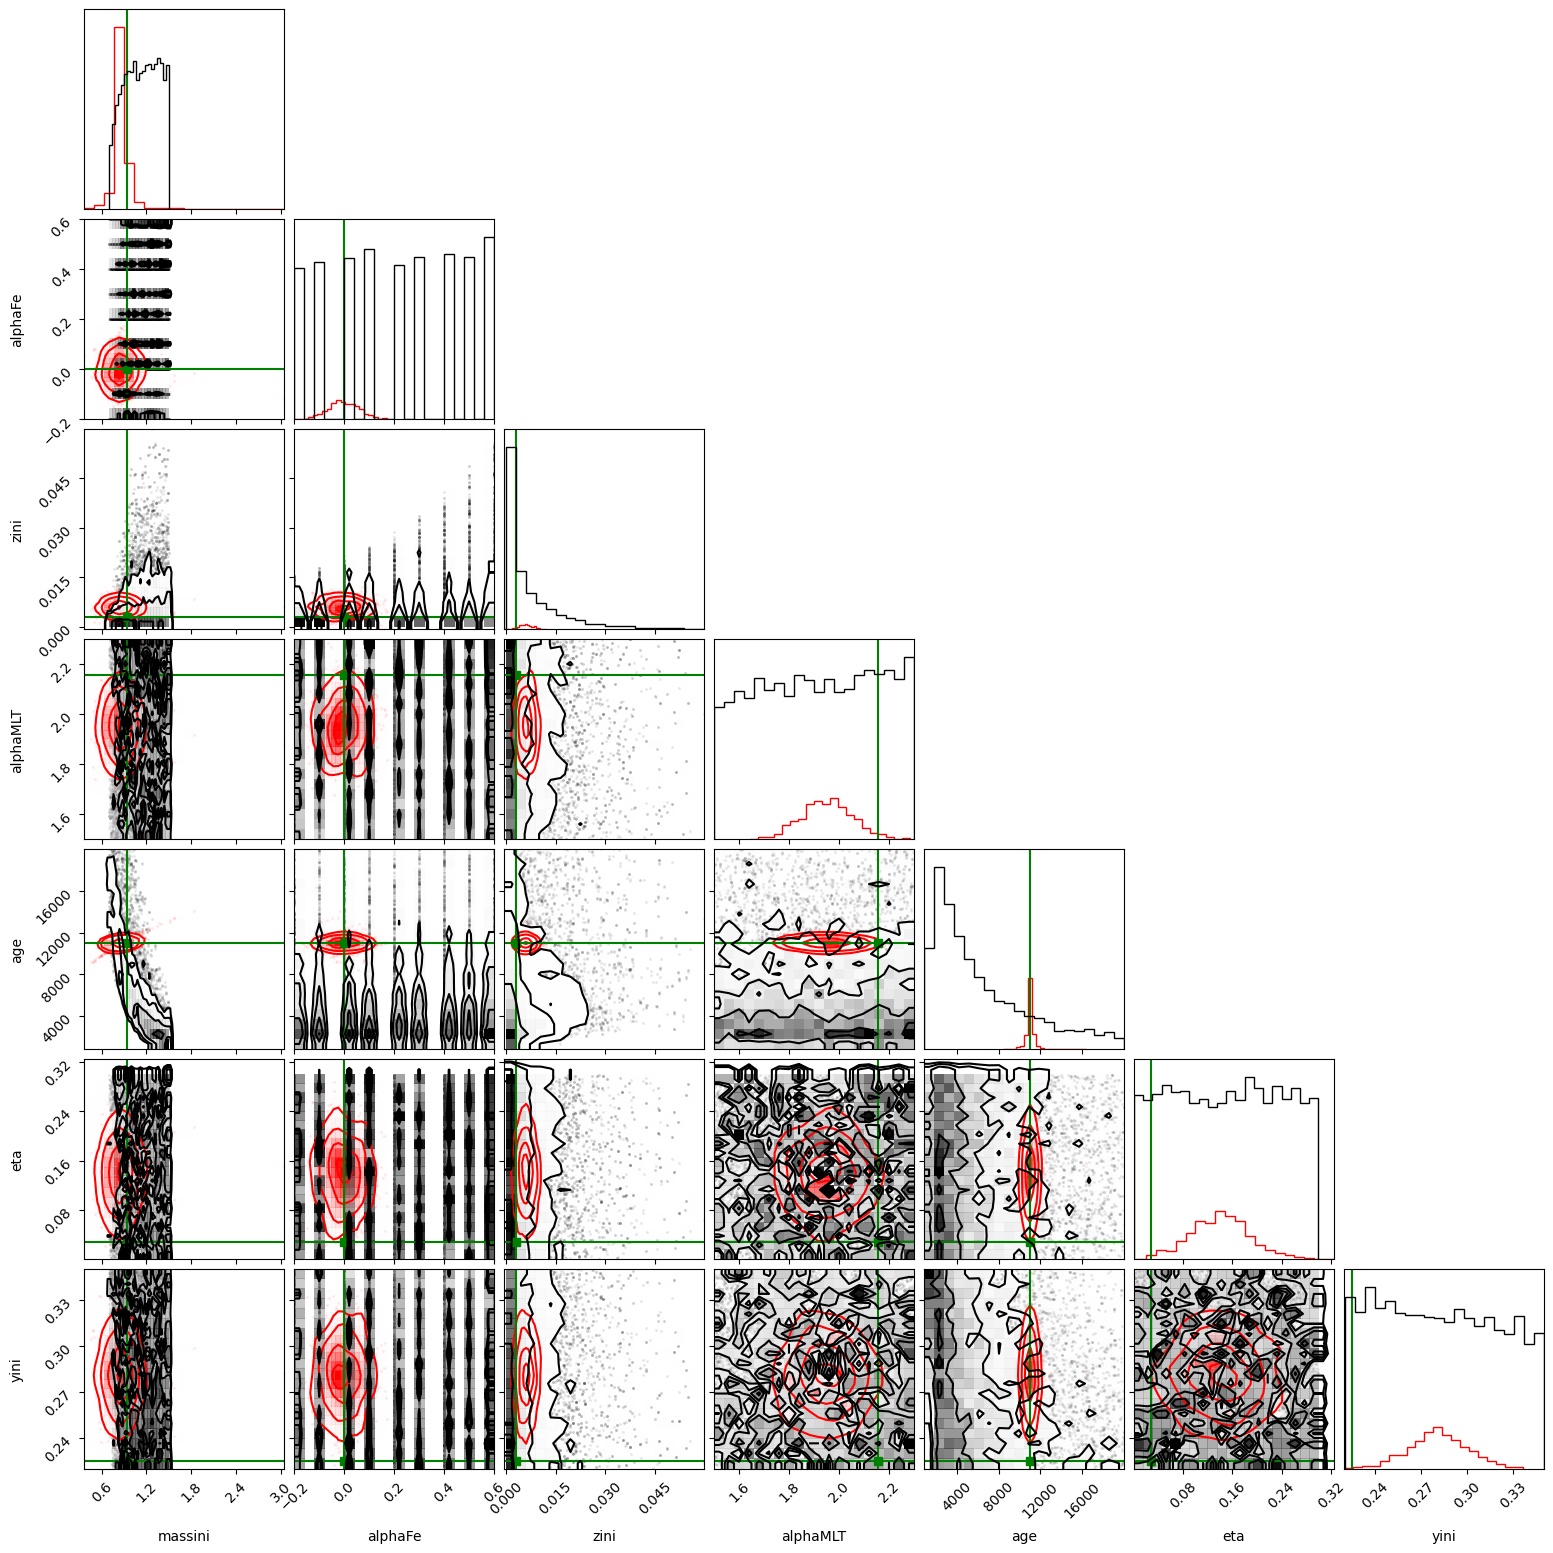

In [252]:
fig = corner.corner(data, group="prior", var_names=['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini'],color = 'red', coords = {'star': 0}, smooth = True, truths = cluster_df[['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini']].loc[0].values, truth_color = 'green')

corner.corner(df_test[['massini', 'alphaFe', 'zini', 'alphaMLT', 'age', 'eta', 'yini']], fig = fig, zorder = 0, alpha = 0.5)
plt.show()

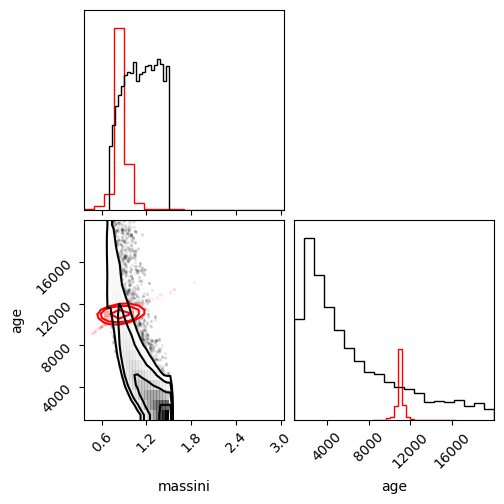

In [253]:
fig = corner.corner(data, group="prior", var_names=['massini', 'age',],color = 'red', coords = {'star': 0}, smooth = True)
corner.corner(df_test[['massini', 'age',]], fig = fig, zorder = 0, alpha = 0.5, smooth = True)
plt.show()

And now for the observables;

# Now to Fit

In [262]:
num_warmup, num_samples = 1000, 1000

num_chains = 2

sampler = NUTS(cluster_model, target_accept_prob=0.8, find_heuristic_step_size=True, init_strategy=numpyro.infer.init_to_median) #May be worth trying init_to_sample

mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)

/tmp/ipykernel_493660/2866301642.py:7: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(sampler, num_warmup=num_warmup, num_samples=num_samples, num_chains=num_chains)


In [263]:
mcmc.run(jax.random.PRNGKey(0),  uncs=phys_unc, obs=cluster)

mcmc.print_summary()

sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [07:14<00:00,  4.60it/s, 1023 steps of size 1.34e-04. acc. prob=0.89]


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
       age[0]  10972.50     19.73  10972.68  10952.96  10992.40      1.00    525.15
       age[1]  11055.92      8.69  11055.71  11047.03  11064.40      1.00    248.76
       age[2]  11035.14     23.00  11035.25  11012.26  11058.25      1.00    476.35
       age[3]  11059.01     66.96  11059.03  10992.09  11125.97      1.00   2050.60
       age[4]  10998.31     10.37  10998.59  10988.23  11008.95      1.00    323.28
       age[5]  11069.68     39.76  11069.64  11029.89  11109.39      1.00    711.34
       age[6]  11015.85     29.95  11015.73  10985.78  11045.68      1.00   1294.89
       age[7]  11046.99     66.95  11046.82  10979.89  11113.75      1.00   1263.41
       age[8]  10945.00      6.91  10944.91  10938.00  10951.81      1.00   1105.67
       age[9]  11027.95     27.48  11028.01  11000.53  11055.48      1.00   1426.42
   alphaFe[0]      0.01      0.01      0.01     -0.01      0.03      1.07  

Now we do a posterior predictive check to make sure everything makes sense

Plotting with arviz

In [26]:
posterior = mcmc.get_samples(group_by_chain=True)
sample_stats = mcmc.get_extra_fields(group_by_chain=True)

rng, key = jax.random.split(jax.random.PRNGKey(0))
posterior_predictive = Predictive(cluster_model, posterior_samples=posterior, parallel=True, batch_ndims=2)
#y = posterior_predictive(key,  obs=None, \
#                         uncs=uncert, )["y"]

#for i, key in enumerate(model_outputs.outputs):
#    posterior[key] = y[..., i]

sample_stats = mcmc.get_extra_fields(group_by_chain=True)

data += az.from_dict(posterior, sample_stats=sample_stats, coords=coords, dims=dims)
data

TypeError: Concatenating overlapping groups is not supported unless `dim` is defined. Valid dimensions are `chain` and `draw`. Alternatively, use extend to combine InferenceData with overlapping groups

In [264]:
posterior

NameError: name 'posterior' is not defined

/home/hatte/miniconda3/envs/py312-nn/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/hatte/miniconda3/envs/py312-nn/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/hatte/miniconda3/envs/py312-nn/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/hatte/miniconda3/envs/py312-nn/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/home/hatte/miniconda3/envs/py31

array([[<Axes: title={'center': 'LPhot_out'}>,
        <Axes: title={'center': 'LPhot_out'}>],
       [<Axes: title={'center': 'age'}>, <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'alphaFe'}>,
        <Axes: title={'center': 'alphaFe'}>],
       [<Axes: title={'center': 'alphaMLT'}>,
        <Axes: title={'center': 'alphaMLT'}>],
       [<Axes: title={'center': 'eta'}>, <Axes: title={'center': 'eta'}>],
       [<Axes: title={'center': 'massini'}>,
        <Axes: title={'center': 'massini'}>],
       [<Axes: title={'center': 'mu_age'}>,
        <Axes: title={'center': 'mu_age'}>],
       [<Axes: title={'center': 'mu_age_beta'}>,
        <Axes: title={'center': 'mu_age_beta'}>],
       [<Axes: title={'center': 'mu_eta'}>,
        <Axes: title={'center': 'mu_eta'}>],
       [<Axes: title={'center': 'mu_eta_beta'}>,
        <Axes: title={'center': 'mu_eta_beta'}>],
       [<Axes: title={'center': 'mu_yini'}>,
        <Axes: title={'center': 'mu_yini'}>],
       [<Axes

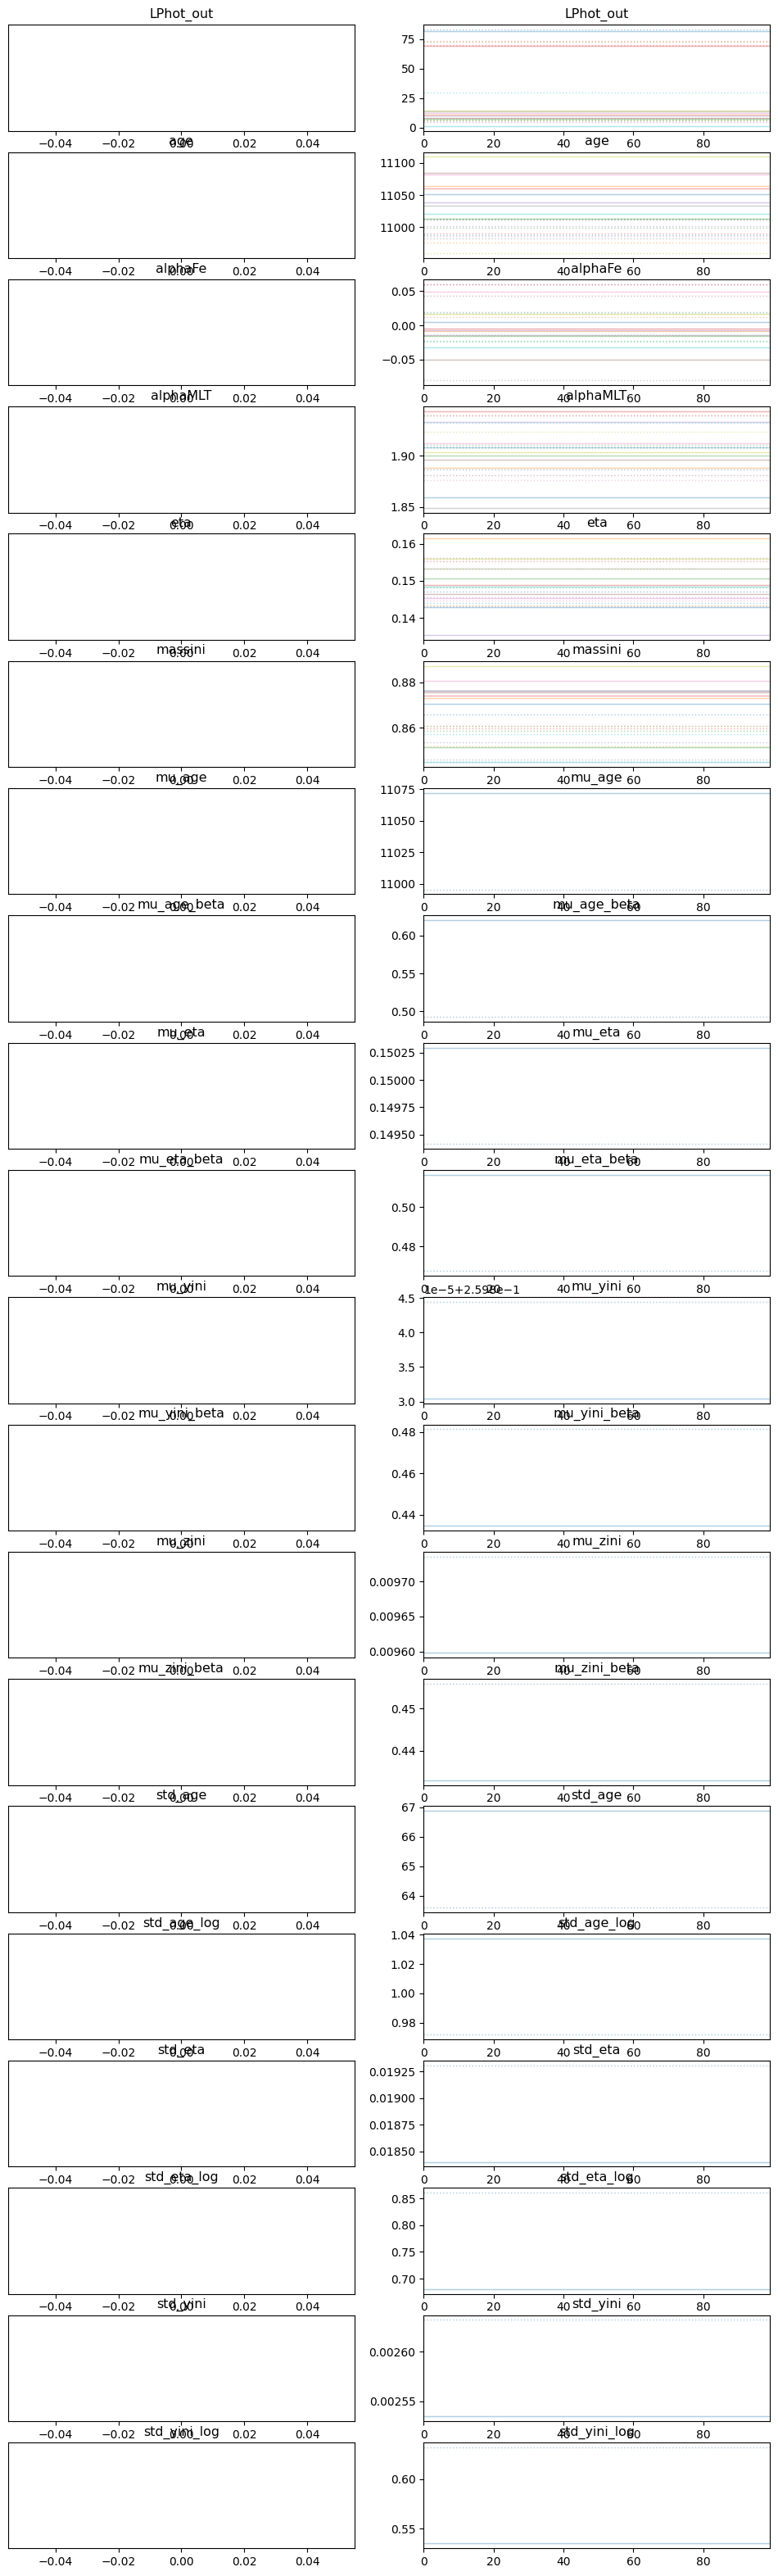

In [23]:
stat_funcs = {
    "q_16": lambda x: np.quantile(x, .16),
    "q_50": lambda x: np.quantile(x, .5),
    "q_84": lambda x: np.quantile(x, .84),
}

az.summary(data, fmt="xarray", stat_funcs=stat_funcs)
az.plot_trace(data,)

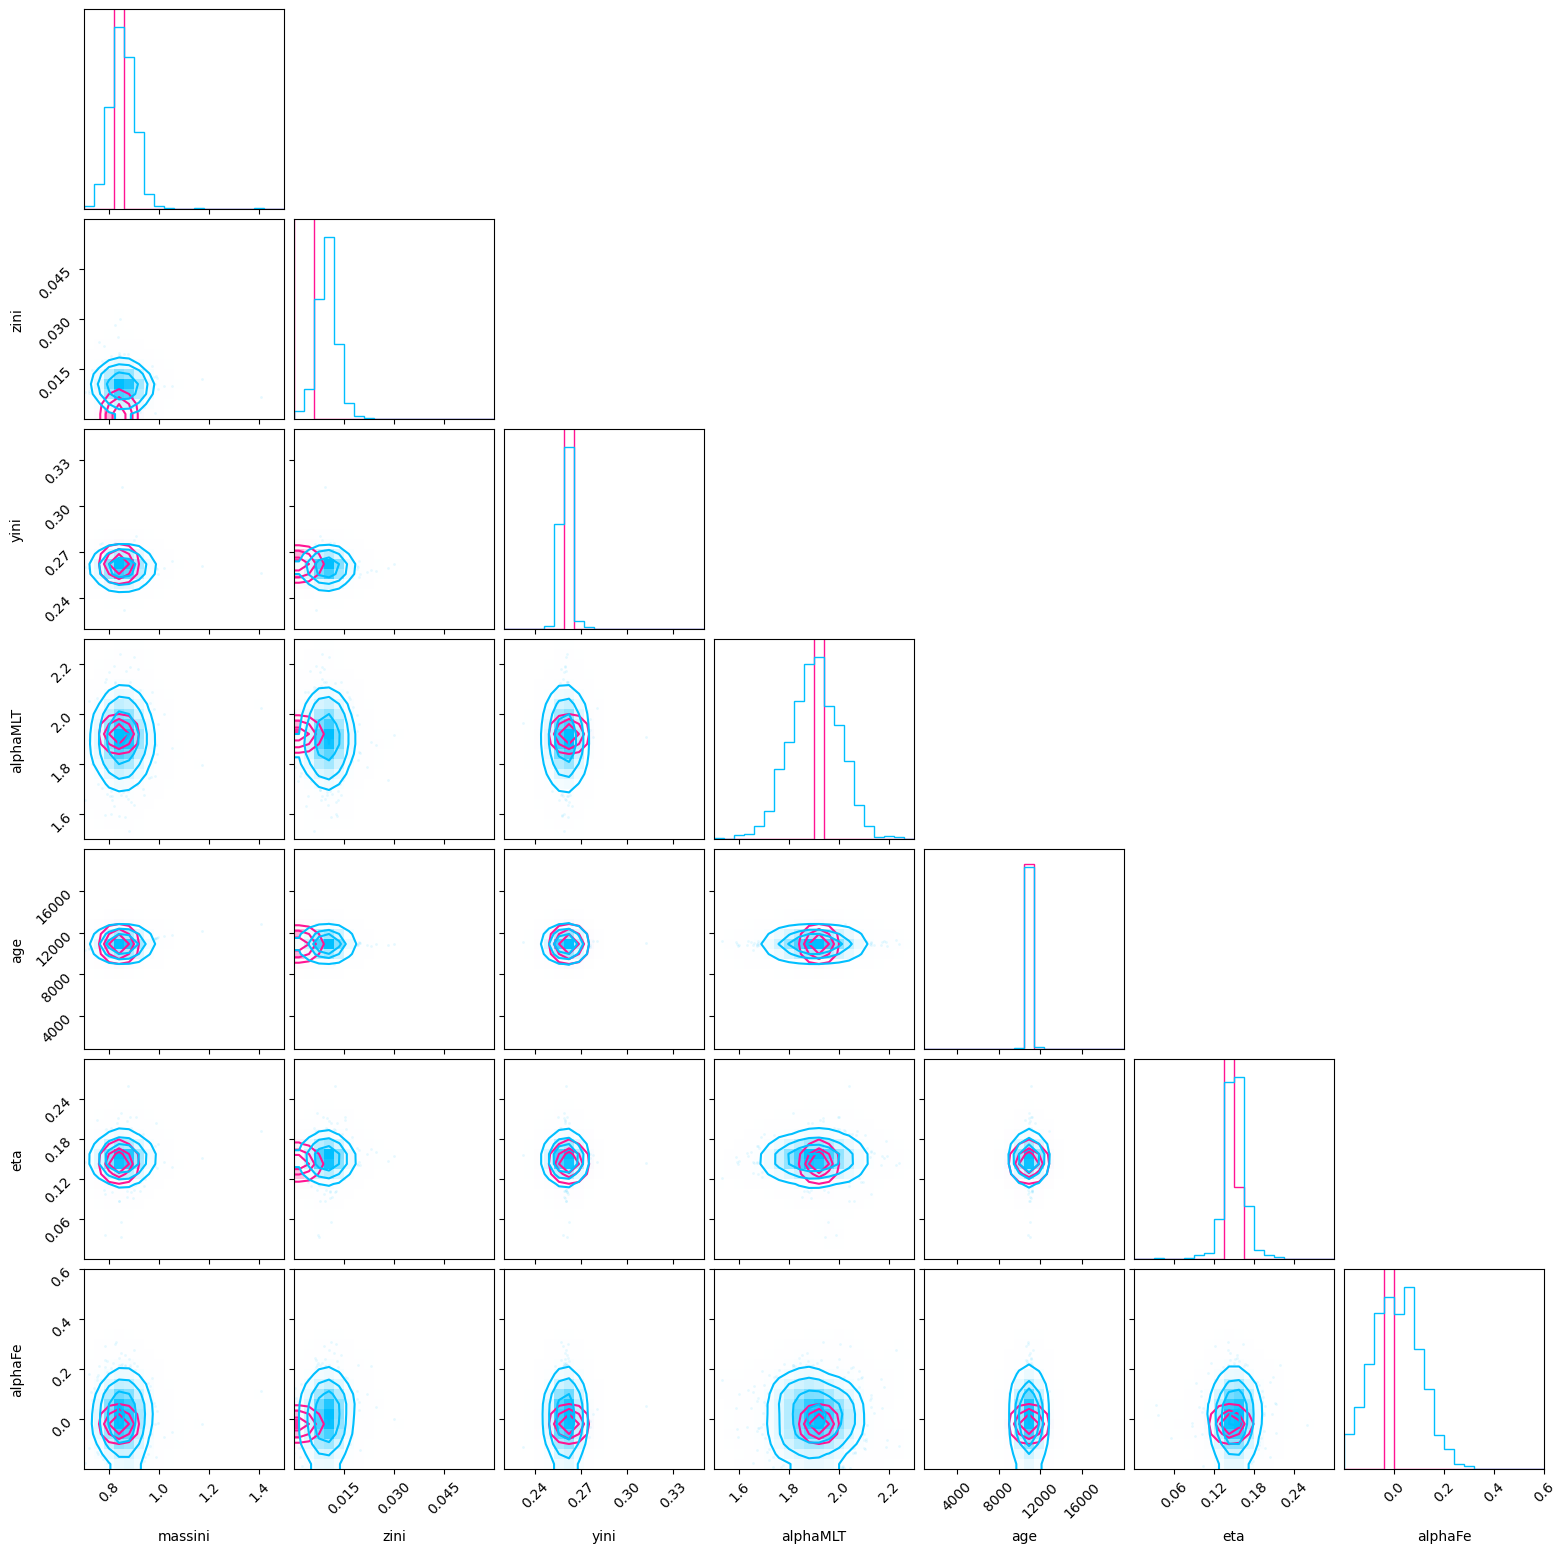

In [598]:
ranges = [(np.min(df_test[i].values), np.max(df_test[i].values)) for i in model_outputs.inputs]
#truths_inputs = [cluster[i].values[0] for i in model_outputs.inputs]
fig = corner.corner(data, group="posterior", var_names = model_outputs.inputs, coords = {'star':9}, color = 'deeppink', range = ranges, zorder = 1, weights = np.ones(2*num_samples)/(2*num_samples), smooth = True, plot_datapoints = True)
#corner.corner(df_test[model_outputs.inputs],zorder = 0, alpha = 0.5, fig = fig)
corner.corner(data, group="prior", var_names=model_outputs.inputs, \
                     coords = {'star':0}, fig = fig, range = ranges, zorder = -100, smooth = True, weights = np.ones(1000)/(1000), color = 'deepskyblue')
#fig.savefig(f'../figs/hierarchical-test-nstars-{int(num_stars)}-inputs.png', bbox_inches = 'tight', dpi = 150)
plt.show()

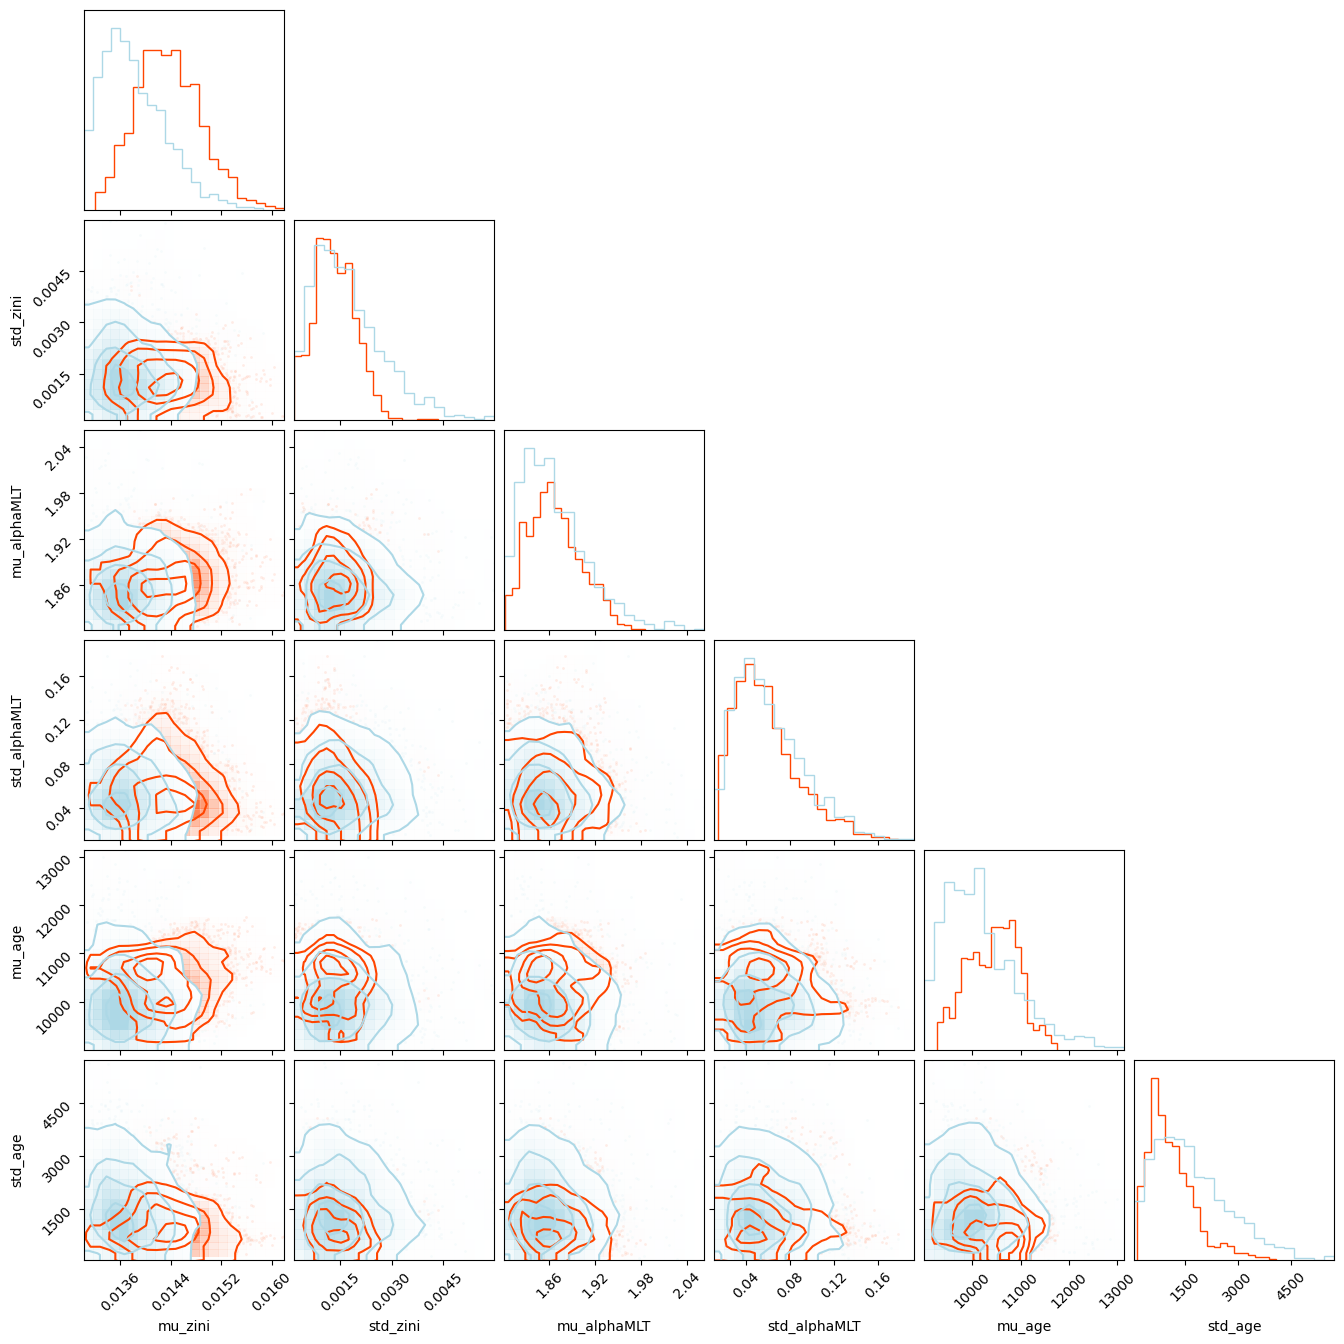

In [189]:

fig = corner.corner(data, group="posterior", var_names =hierarchical_params,  zorder = 1, weights = np.ones(2*num_samples)/(2*num_samples), \
                    color= 'orangered', smooth = True)
corner.corner(data, group="prior", var_names=hierarchical_params, \
                      fig = fig,  weights = np.ones(1000)/(1000), \
                      smooth = True, color = 'lightblue', truth_color = 'black')
fig.savefig(f'../figs/hierarchical-test-nstars-{int(num_stars)}-hierarchical-params.png', bbox_inches = 'tight', dpi = 150)
plt.show()

In [23]:
0.014 - 0.001

0.013000000000000001